# **Evaluation**

In [ ]:
import json
import os
import sys

sys.path.append("../../")

from datetime import datetime, timedelta
from random import random, seed

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
from metrics import (
    get_budget_efficiency,
    get_dietary_constraint_compliance,
    get_expiry_weighted_utilisation_score,
    get_food_waste_score,
    get_ingredient_utilisation_score,
    get_nutritional_target_score,
    get_pantry_coverage_score,
    get_variety_score,
)
from openai import OpenAI
from pandas import DataFrame
from tqdm.auto import tqdm

from engines import (
    GAMealPlanner,
    ILPMealPlanner,
    LLMMealPlanner,
    MealPlanner,
    RandomMealPlanner,
    filter_and_add_recipes,
    get_pantry_ingredient,
    load_all_ingredients,
    make_preferences,
)
from models import DietaryTag, MealPlanningEnvironment, NutritionalInformation, Pantry, Recipe

load_dotenv()

True

## Evaluation Environment Setup

In [2]:
seed(1)

In [3]:
user_preferences = make_preferences()

In [4]:
all_ingredients = load_all_ingredients(filepath="../../recipe_extraction/supplemented_structured_ingredients.json")

## Scenario Construction

Fixed test scenarios are constructed below. Each scenario is a `(pantry, preferences)` pair that is later used to build a `MealPlanningEnvironment` for every planner.

| # | Scenario | Budget | Pantry | Preferences |
|---|---|---|---|---|
| 1 | Standard | €50 | ~10 items | none |
| 2 | Low Budget | €15 | sparse | none |
| 3 | Overcrowded Pantry | €50 | 20+ items, 8+ expiring ≤3 days | none |
| 4 | Dietary Restrictions (Vegan + Gluten-Free) | €50 | mixed | vegan + gluten-free |
| 5 | Dietary Restrictions (Lactose-Free + Vegetarian) | €50 | mixed | lactose-free + vegetarian |
| 6 | High Nutritional Targets | €50 | balanced | 3000 kcal/day, 150 g protein |

In [5]:
CURRENT_DATE = datetime.now()

In [6]:
def build_scenario_pantry(
    ingredient_spec: dict[str, tuple[float, int]],
    all_ingredients: list,
    current_date: datetime,
) -> Pantry:
    """
    Builds a Pantry for a scenario

    :param ingredient_spec: mapping of ingredient name to (quantity_grams, days_until_expiry)
    :type ingredient_spec: dict[str, tuple[float, int]]
    :param all_ingredients: full ingredient list loaded from supplemented_structured_ingredients.json
    :type all_ingredients: list
    :param current_date: reference date used to compute expiry dates
    :type current_date: datetime

    :return: Pantry object populated with the specified ingredients
    :rtype: Pantry
    """
    pantry = Pantry()
    for name, (quantity, days) in ingredient_spec.items():
        pantry_ingredient = get_pantry_ingredient(
            name,
            current_date + timedelta(days=days),
            all_ingredients,
        )
        pantry.add(pantry_ingredient, quantity)
    return pantry

### Scenario 1 (Standard)

10 pantry items, €50 budget, no dietary restrictions.

In [7]:
scenario_1_pantry_spec = {
    "chicken breast": (800, 5),
    "broccoli": (600, 4),
    "rice": (1000, 10),
    "pasta": (500, 14),
    "tomato": (400, 3),
    "onion": (300, 7),
    "garlic": (100, 14),
    "olive oil": (250, 30),
    "eggs": (360, 10),
    "carrot": (400, 6),
}

scenario_1_pantry = build_scenario_pantry(scenario_1_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_1_preferences = make_preferences(weekly_budget=50.0)

print(f"Scenario 1 pantry items: {len(scenario_1_pantry.ingredients)}")

Scenario 1 pantry items: 10


### Scenario 2 (Low Budget)

Sparse pantry (4 items), €15 budget, no dietary restrictions.

In [8]:
scenario_2_pantry_spec = {
    "rice": (500, 10),
    "onion": (200, 7),
    "garlic": (100, 14),
    "tomato": (300, 4),
}

scenario_2_pantry = build_scenario_pantry(scenario_2_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_2_preferences = make_preferences(weekly_budget=15.0)

print(f"Scenario 2 pantry items: {len(scenario_2_pantry.ingredients)}")

Scenario 2 pantry items: 4


### Scenario 3 (Overcrowded Pantry)

20+ pantry items, 8 of which expire within 3 days, €50 budget, no dietary restrictions.

In [9]:
scenario_3_pantry_spec = {
    # expiring very soon (<=3 days)
    "chicken breast": (600, 1),
    "broccoli": (400, 2),
    "spinach": (200, 1),
    "mushrooms": (300, 2),
    "tomato": (400, 3),
    "avocado": (250, 2),
    "Greek yogurt": (400, 3),
    "milk": (500, 1),
    # items with longer shelf life
    "rice": (1000, 10),
    "pasta": (800, 14),
    "onion": (500, 7),
    "garlic": (150, 14),
    "olive oil": (300, 30),
    "eggs": (360, 10),
    "carrot": (600, 7),
    "celery": (400, 5),
    "potato": (1000, 12),
    "sweet potato": (600, 8),
    "lentils": (500, 60),
    "chickpeas": (400, 60),
    "black beans": (400, 60),
    "oats": (600, 90),
}

scenario_3_pantry = build_scenario_pantry(scenario_3_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_3_preferences = make_preferences(weekly_budget=50.0)

num_expiring_soon = sum(1 for days in scenario_3_pantry_spec.values() if days[1] <= 3)

print(f"Scenario 3 pantry items: {len(scenario_3_pantry.ingredients)} ({num_expiring_soon} expiring <=3 days)")

Scenario 3 pantry items: 22 (8 expiring <=3 days)


### Scenario 4 (Dietary Restrictions)

Mixed plant-based pantry, €50 budget, vegan + gluten-free preferences.

In [10]:
scenario_4_pantry_spec = {
    "tofu": (500, 5),
    "chickpeas": (400, 60),
    "black beans": (400, 60),
    "lentils": (500, 60),
    "spinach": (300, 3),
    "broccoli": (400, 4),
    "tomato": (400, 4),
    "garlic": (100, 14),
    "onion": (300, 7),
    "olive oil": (250, 30),
    "carrot": (400, 6),
    "corn": (300, 5),
}

scenario_4_pantry = build_scenario_pantry(scenario_4_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_4_preferences = make_preferences(weekly_budget=50.0, is_vegan=True, requires_gluten_free=True)

print(f"Scenario 4 pantry items: {len(scenario_4_pantry.ingredients)}")
print(
    f"\tis_vegan={scenario_4_preferences.is_vegan}, requires_gluten_free={scenario_4_preferences.requires_gluten_free}"
)

Scenario 4 pantry items: 12
	is_vegan=True, requires_gluten_free=True


### Scenario 5 (Lactose-Free + Vegetarian)

Mixed plant-based pantry, €50 budget, lactose-free + vegetarian preferences.

In [11]:
scenario_5_pantry_spec = {
    "tofu": (400, 5),
    "eggs": (360, 10),
    "lentils": (500, 60),
    "chickpeas": (400, 60),
    "spinach": (300, 3),
    "broccoli": (400, 4),
    "tomato": (400, 4),
    "garlic": (100, 14),
    "onion": (300, 7),
    "olive oil": (250, 30),
    "carrot": (400, 6),
    "rice": (800, 14),
}

scenario_5_pantry = build_scenario_pantry(scenario_5_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_5_preferences = make_preferences(weekly_budget=50.0, is_vegetarian=True, requires_lactose_free=True)

print(f"Scenario 5 pantry items: {len(scenario_5_pantry.ingredients)}")
print(
    f"\tis_vegetarian={scenario_5_preferences.is_vegetarian}, requires_lactose_free={scenario_5_preferences.requires_lactose_free}"
)

Scenario 5 pantry items: 12
	is_vegetarian=True, requires_lactose_free=True


### Scenario 6 (High Nutritional Targets)

Balanced pantry, €50 budget, 3000 kcal/day and 150 g protein/day targets.

In [12]:
scenario_6_pantry_spec = {
    "chicken breast": (1200, 5),
    "salmon": (600, 3),
    "eggs": (720, 10),
    "beef": (800, 3),
    "rice": (1000, 14),
    "oats": (600, 90),
    "milk": (1000, 7),
    "broccoli": (600, 4),
    "sweet potato": (800, 8),
    "olive oil": (300, 30),
}

scenario_6_pantry = build_scenario_pantry(scenario_6_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_6_preferences = make_preferences(
    weekly_budget=50.0,
    calorie_target=3000.0,
    protein_target=150.0,
)

print(f"Scenario 6 pantry items: {len(scenario_6_pantry.ingredients)}")
print(
    f"\tcalorie_target={scenario_6_preferences.calorie_target_per_day} kcal/day, protein_target={scenario_6_preferences.protein_target_per_day} g/day"
)

Scenario 6 pantry items: 10
	calorie_target=3000.0 kcal/day, protein_target=150.0 g/day


### All Scenarios

Collect all scenarios into a list for use in the evaluation runner loop.

In [13]:
NUM_FILTERED_RECIPES = 100
NUM_EXTRA_RECIPES = 50

In [14]:
with open("../../recipe_extraction/supplemented_structured_recipes.json", "r") as file:
    all_recipes = json.load(file)

In [15]:
tag_map = {
    "VEGETARIAN": DietaryTag.VEGETARIAN,
    "VEGAN": DietaryTag.VEGAN,
    "GLUTEN_FREE": DietaryTag.GLUTEN_FREE,
    "LACTOSE_FREE": DietaryTag.LACTOSE_FREE,
}

parsed_recipes = []

for unparsed_recipe in all_recipes:
    ingredients = {ingredient["ingredient"]: ingredient["quantity"] for ingredient in unparsed_recipe["ingredients"]}
    dietary_tags = [tag_map[tag] for tag in unparsed_recipe.get("dietary_tags", []) if tag in tag_map]

    recipe = Recipe(
        name=unparsed_recipe["name"],
        ingredients=ingredients,
        dietary_tags=dietary_tags,
        instructions=unparsed_recipe.get("instructions", []),
    )

    nutritional_information = unparsed_recipe["nutritional_information"]

    recipe.nutritional_information = NutritionalInformation(
        calories=nutritional_information.get("calories"),
        carbohydrates=nutritional_information.get("carbohydrates"),
        sugar=nutritional_information.get("sugar"),
        protein=nutritional_information.get("protein"),
        fat=nutritional_information.get("fat"),
        saturated_fat=nutritional_information.get("saturated_fat"),
        fiber=nutritional_information.get("fiber"),
        sodium=nutritional_information.get("sodium"),
        is_gluten_free=nutritional_information.get("is_gluten_free"),
        is_lactose_free=nutritional_information.get("is_lactose_free"),
        is_vegetarian=nutritional_information.get("is_vegetarian"),
        is_vegan=nutritional_information.get("is_vegan"),
    )

    parsed_recipes.append(recipe)

all_recipes = parsed_recipes.copy()

In [16]:
scenario_1_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_1_pantry.ingredients],
    NUM_FILTERED_RECIPES,
    NUM_EXTRA_RECIPES,
)
scenario_2_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_2_pantry.ingredients],
    NUM_FILTERED_RECIPES,
    NUM_EXTRA_RECIPES,
)
scenario_3_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_3_pantry.ingredients],
    NUM_FILTERED_RECIPES * 2,
    NUM_EXTRA_RECIPES * 2,
)
scenario_4_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_4_pantry.ingredients],
    NUM_FILTERED_RECIPES,
    NUM_EXTRA_RECIPES,
)
scenario_5_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_5_pantry.ingredients],
    NUM_FILTERED_RECIPES,
    NUM_EXTRA_RECIPES,
)
scenario_6_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_6_pantry.ingredients],
    NUM_FILTERED_RECIPES,
    NUM_EXTRA_RECIPES,
)

In [17]:
scenario_names = [
    "Scenario 1: Standard",
    "Scenario 2: Low Budget",
    "Scenario 3: Overcrowded Pantry",
    "Scenario 4: Dietary Restrictions (Vegan + Gluten-Free)",
    "Scenario 5: Dietary Restrictions (Lactose-Free + Vegetarian)",
    "Scenario 6: High Nutritional Targets",
]

In [18]:
all_ingredient_names = []

for recipe in [
    *scenario_1_recipes,
    *scenario_2_recipes,
    *scenario_3_recipes,
    *scenario_4_recipes,
    *scenario_5_recipes,
    *scenario_6_recipes,
]:
    for ingredient_name in recipe.ingredients.keys():
        all_ingredient_names.append(ingredient_name)

In [19]:
all_ingredient_costs = {}

for ingredient_name in sorted(set(all_ingredient_names)):
    all_ingredient_costs[ingredient_name] = random()

In [20]:
scenario_environments: list[MealPlanningEnvironment] = []

for pantry, recipes, preferences in [
    (scenario_1_pantry, scenario_1_recipes, scenario_1_preferences),
    (scenario_2_pantry, scenario_2_recipes, scenario_2_preferences),
    (scenario_3_pantry, scenario_3_recipes, scenario_3_preferences),
    (scenario_4_pantry, scenario_4_recipes, scenario_4_preferences),
    (scenario_5_pantry, scenario_5_recipes, scenario_5_preferences),
    (scenario_6_pantry, scenario_6_recipes, scenario_6_preferences),
]:
    environment = MealPlanningEnvironment(
        pantry=pantry,
        recipes=recipes,
        preferences=preferences,
        ingredient_costs=all_ingredient_costs,
    )

    scenario_environments.append(environment)

In [21]:
planner_metrics: dict[tuple[str, int], dict[str, float]] = {}
best_meal_plans: dict[tuple[str, int], list[list[Recipe]]] = {}
best_fitness_scores: dict[tuple[str, int], float | None] = {}
ilp_solve_statuses: dict[tuple[str, int], str] = {}

In [22]:
def evaluate_planner(
    scenario_index: int,
    meal_planner: MealPlanner,
    generation_params: dict[str, any] | None = None,
    num_repetitions: int = 1,
) -> None:
    """
    Evaluates a meal planner by generating a meal plan and computing various metrics on it, while also measuring the computation runtime

    :param scenario_index: the index of the scenario to evaluate
    :type scenario_index: int
    :param meal_planner: the meal planner to evaluate
    :type meal_planner: MealPlanner
    :param generation_params: the parameters to pass to the meal planner if needed
    :type generation_params: dict[str, any]
    :param num_repetitions: the number of times to repeat meal plan generation for averaging metrics
    :type num_repetitions: int
    """

    environment = meal_planner.meal_planning_environment

    runtime_start = datetime.now()

    if generation_params is None:
        generation_params = {}

    ingredient_utilisation_scores = np.array([])
    expiry_weighted_utilisation_scores = np.array([])
    food_waste_scores = np.array([])
    dietary_constraint_compliance_scores = np.array([])
    nutritional_target_scores = np.array([])
    budget_efficiency_scores = np.array([])
    pantry_coverage_scores = np.array([])
    variety_scores = np.array([])
    runtime_seconds = np.array([])

    best_meal_plan_recipes = None
    best_fitness_score = None

    for _ in range(num_repetitions):
        meal_plan, fitness_score = meal_planner.generate_meal_plan(**generation_params)

        runtime_end = datetime.now()

        meal_plan_recipes = [
            [environment.recipes[int(index)] for index in meal_plan[i : i + 3]] for i in range(0, len(meal_plan), 3)
        ]

        ingredient_utilisation_scores = np.append(
            ingredient_utilisation_scores,
            get_ingredient_utilisation_score(meal_plan=meal_plan_recipes, pantry=environment.pantry),
        )

        expiry_weighted_utilisation_scores = np.append(
            expiry_weighted_utilisation_scores,
            get_expiry_weighted_utilisation_score(
                meal_plan=meal_plan_recipes, pantry=environment.pantry, current_date=CURRENT_DATE
            ),
        )

        food_waste_scores = np.append(
            food_waste_scores,
            get_food_waste_score(meal_plan=meal_plan_recipes, pantry=environment.pantry, current_date=CURRENT_DATE),
        )

        dietary_constraint_compliance_scores = np.append(
            dietary_constraint_compliance_scores,
            get_dietary_constraint_compliance(meal_plan=meal_plan_recipes, user_preferences=environment.preferences),
        )

        nutritional_target_scores = np.append(
            nutritional_target_scores,
            get_nutritional_target_score(meal_plan=meal_plan_recipes, user_preferences=environment.preferences),
        )

        budget_efficiency_scores = np.append(
            budget_efficiency_scores,
            get_budget_efficiency(
                meal_plan=meal_plan_recipes,
                pantry=environment.pantry,
                ingredient_costs=environment.ingredient_costs,
                weekly_budget=environment.preferences.weekly_budget,
            ),
        )

        pantry_coverage_scores = np.append(
            pantry_coverage_scores,
            get_pantry_coverage_score(
                meal_plan=meal_plan_recipes,
                pantry=environment.pantry,
            ),
        )

        variety_scores = np.append(variety_scores, get_variety_score(meal_plan=meal_plan_recipes))

        runtime_seconds = np.append(runtime_seconds, (runtime_end - runtime_start).total_seconds())

        if best_fitness_score is None or fitness_score > best_fitness_score:
            best_fitness_score = fitness_score
            best_meal_plan_recipes = meal_plan_recipes

        if hasattr(meal_planner, "get_solve_status"):
            ilp_solve_statuses[(meal_planner.__class__.__name__, scenario_index)] = meal_planner.get_solve_status()

    planner_metrics[(meal_planner.__class__.__name__, scenario_index)] = {
        "ingredient_utilisation_score_mean": ingredient_utilisation_scores.mean(),
        "ingredient_utilisation_score_std": np.std(ingredient_utilisation_scores),
        "expiry_weighted_utilisation_score_mean": expiry_weighted_utilisation_scores.mean(),
        "expiry_weighted_utilisation_score_std": np.std(expiry_weighted_utilisation_scores),
        "food_waste_score_mean": food_waste_scores.mean(),
        "food_waste_score_std": np.std(food_waste_scores),
        "dietary_constraint_compliance_mean": dietary_constraint_compliance_scores.mean(),
        "dietary_constraint_compliance_std": np.std(dietary_constraint_compliance_scores),
        "nutritional_target_score_mean": nutritional_target_scores.mean(),
        "nutritional_target_score_std": np.std(nutritional_target_scores),
        "budget_efficiency_mean": budget_efficiency_scores.mean(),
        "budget_efficiency_std": np.std(budget_efficiency_scores),
        "pantry_coverage_score_mean": pantry_coverage_scores.mean(),
        "pantry_coverage_score_std": np.std(pantry_coverage_scores),
        "variety_score_mean": variety_scores.mean(),
        "variety_score_std": np.std(variety_scores),
        "runtime_seconds_mean": runtime_seconds.mean(),
        "runtime_seconds_std": np.std(runtime_seconds),
    }

    best_meal_plans[(meal_planner.__class__.__name__, scenario_index)] = best_meal_plan_recipes

    best_fitness_scores[(meal_planner.__class__.__name__, scenario_index)] = best_fitness_score

## Evaluation

### *Random Meal Planner*

In [23]:
RANDOM_MEAL_PLANNER_SEED = 1
NUM_RANDOM_REPETITIONS = 10

### *GA Meal Planner*

In [24]:
with open("../best_ga_meal_planner_hyperparameters.json", "r") as file:
    best_params = json.load(file)

In [25]:
print(best_params)

{'population_size': 180, 'num_parents_mating': 48, 'parent_selection_type': 'sss', 'K_tournament': 3, 'keep_elitism': 0, 'crossover_type': 'single_point', 'crossover_probability': 1.0, 'mutation_type': 'inversion', 'mutation_probability': 0.09}


In [26]:
GA_MEAL_PLANNER_SEED = 1

### *ILP Meal Planner*

In [27]:
ILP_MEAL_PLANNER_TIME_LIMIT_SECONDS = 600

### *LLM Meal Planner*

In [28]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

### *Evaluating all Planners*

In [29]:
all_planner_params = [
    {},
    {**best_params, "generation_print_interval": None, "seed": GA_MEAL_PLANNER_SEED},
    {"time_limit": ILP_MEAL_PLANNER_TIME_LIMIT_SECONDS},
    {},
]

In [30]:
all_planner_num_repetitions = [
    NUM_RANDOM_REPETITIONS,
    1,
    1,
    1,
]

In [31]:
fitness_score_weights = {
    "pantry_weight": 1.0,
    "waste_weight": 1.0,
    "budget_weight": 1.0,
    "dietary_weight": 1.0,
}

In [32]:
total_steps = len(scenario_environments) * len(all_planner_params)

with tqdm(total=total_steps) as pbar:
    for scenario_index, scenario_environment in enumerate(scenario_environments, start=1):
        random_meal_planner = RandomMealPlanner(
            meal_planning_environment=scenario_environment, random_seed=RANDOM_MEAL_PLANNER_SEED
        )

        ga_meal_planner = GAMealPlanner(meal_planning_environment=scenario_environment, **fitness_score_weights)

        ilp_meal_planner = ILPMealPlanner(meal_planning_environment=scenario_environment, **fitness_score_weights)

        llm_meal_planner = LLMMealPlanner(
            meal_planning_environment=scenario_environment,
            llm_client=client,
            model_name="gpt-5.4-mini",
            prompt_filepath="../LLMMealPlannerPrompt.txt",
        )

        planners = [random_meal_planner, ga_meal_planner, ilp_meal_planner, llm_meal_planner]

        for meal_planner, planner_params, num_repetitions in zip(
            planners, all_planner_params, all_planner_num_repetitions
        ):
            pbar.set_description(
                f"Scenario {scenario_index}/{len(scenario_environments)} with {meal_planner.__class__.__name__}"
            )
            evaluate_planner(
                scenario_index=scenario_index,
                meal_planner=meal_planner,
                generation_params=planner_params,
                num_repetitions=num_repetitions,
            )
            pbar.update(1)

  0%|          | 0/24 [00:00<?, ?it/s]

In [33]:
serialisable_metrics = {f"{planner}|{scenario}": metrics for (planner, scenario), metrics in planner_metrics.items()}

with open("./results/planner_metrics.json", "w") as file:
    json.dump(serialisable_metrics, file, indent=4)

print("Saved metrics to results/planner_metrics.json")

Saved metrics to results/planner_metrics.json


In [34]:
serialisable_best_meal_plans = {
    f"{planner}|{scenario}": [
        [recipe.name for recipe in meal_plan] for meal_plan in best_meal_plans[(planner, scenario)]
    ]
    for (planner, scenario) in best_meal_plans.keys()
}

with open("./results/best_meal_plans.json", "w") as file:
    json.dump(serialisable_best_meal_plans, file, indent=4)

print("Saved best meal plans to results/best_meal_plans.json")

Saved best meal plans to results/best_meal_plans.json


In [35]:
serialisable_best_fitness_scores = {
    f"{planner}|{scenario}": score for (planner, scenario), score in best_fitness_scores.items()
}

with open("./results/best_fitness_scores.json", "w") as file:
    json.dump(serialisable_best_fitness_scores, file, indent=4)

print("Saved best fitness scores to results/best_fitness_scores.json")

Saved best fitness scores to results/best_fitness_scores.json


In [36]:
serialisable_ilp_solve_statuses = {
    f"{planner}|{scenario}": status for (planner, scenario), status in ilp_solve_statuses.items()
}

with open("./results/ilp_solve_statuses.json", "w") as file:
    json.dump(serialisable_ilp_solve_statuses, file, indent=4)

print("Saved ILP solve statuses to results/ilp_solve_statuses.json")
print(serialisable_ilp_solve_statuses)

Saved ILP solve statuses to results/ilp_solve_statuses.json
{'ILPMealPlanner|1': 'Optimal', 'ILPMealPlanner|2': 'Time / iteration limit reached', 'ILPMealPlanner|3': 'Time / iteration limit reached', 'ILPMealPlanner|4': 'Optimal', 'ILPMealPlanner|5': 'Optimal', 'ILPMealPlanner|6': 'Time / iteration limit reached'}


## Evaluation Metrics

In [37]:
sns.set_theme("notebook")
colours = sns.color_palette("husl", len(planner_metrics))

In [43]:
metrics_to_plot = [
    ("ingredient_utilisation_score_mean", "Ingredient Utilisation"),
    ("expiry_weighted_utilisation_score_mean", "Expiry-Weighted Utilisation"),
    ("food_waste_score_mean", "Food Waste"),
    ("dietary_constraint_compliance_mean", "Dietary Constraint Compliance"),
    ("nutritional_target_score_mean", "Nutritional Target Compliance"),
    ("budget_efficiency_mean", "Budget Efficiency"),
    ("pantry_coverage_score_mean", "Pantry Coverage"),
    ("variety_score_mean", "Variety"),
    ("runtime_seconds_mean", "Runtime (seconds)"),
]

In [78]:
def plot_metrics(planner_metrics: dict[str, dict[str, float]], title: str) -> None:
    """
    Plots the specified metrics for each meal planner and scenario as horizontal bar charts

    :param planner_metrics: mapping of (meal_planner_name, scenario_index) to metric values
    :type planner_metrics: dict[str, dict[str, float]]
    :param title: the title for the overall plot
    :type title: str
    """

    fig, axes = plt.subplots(5, 2, figsize=(20, 12), constrained_layout=True)

    for ax, (metric_key, metric_title) in zip(axes.flat, metrics_to_plot):
        for i, (planner, metrics) in enumerate(planner_metrics.items()):
            ax.barh(i, metrics[metric_key], color=colours[i], label=planner)
            ax.text(metrics[metric_key] + 0.01, i, f"{metrics[metric_key]:.2f}", color="black", va="center")

        ax.set_yticks(range(len(planner_metrics)))
        ax.set_yticklabels(planner_metrics.keys())
        ax.set_title(metric_title, fontweight="bold")

    # hide any unused subplots
    for j in range(len(metrics_to_plot), len(axes.flat)):
        axes.flat[j].axis("off")

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.show()

### Scenario 1

In [79]:
scenario_1_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 1}

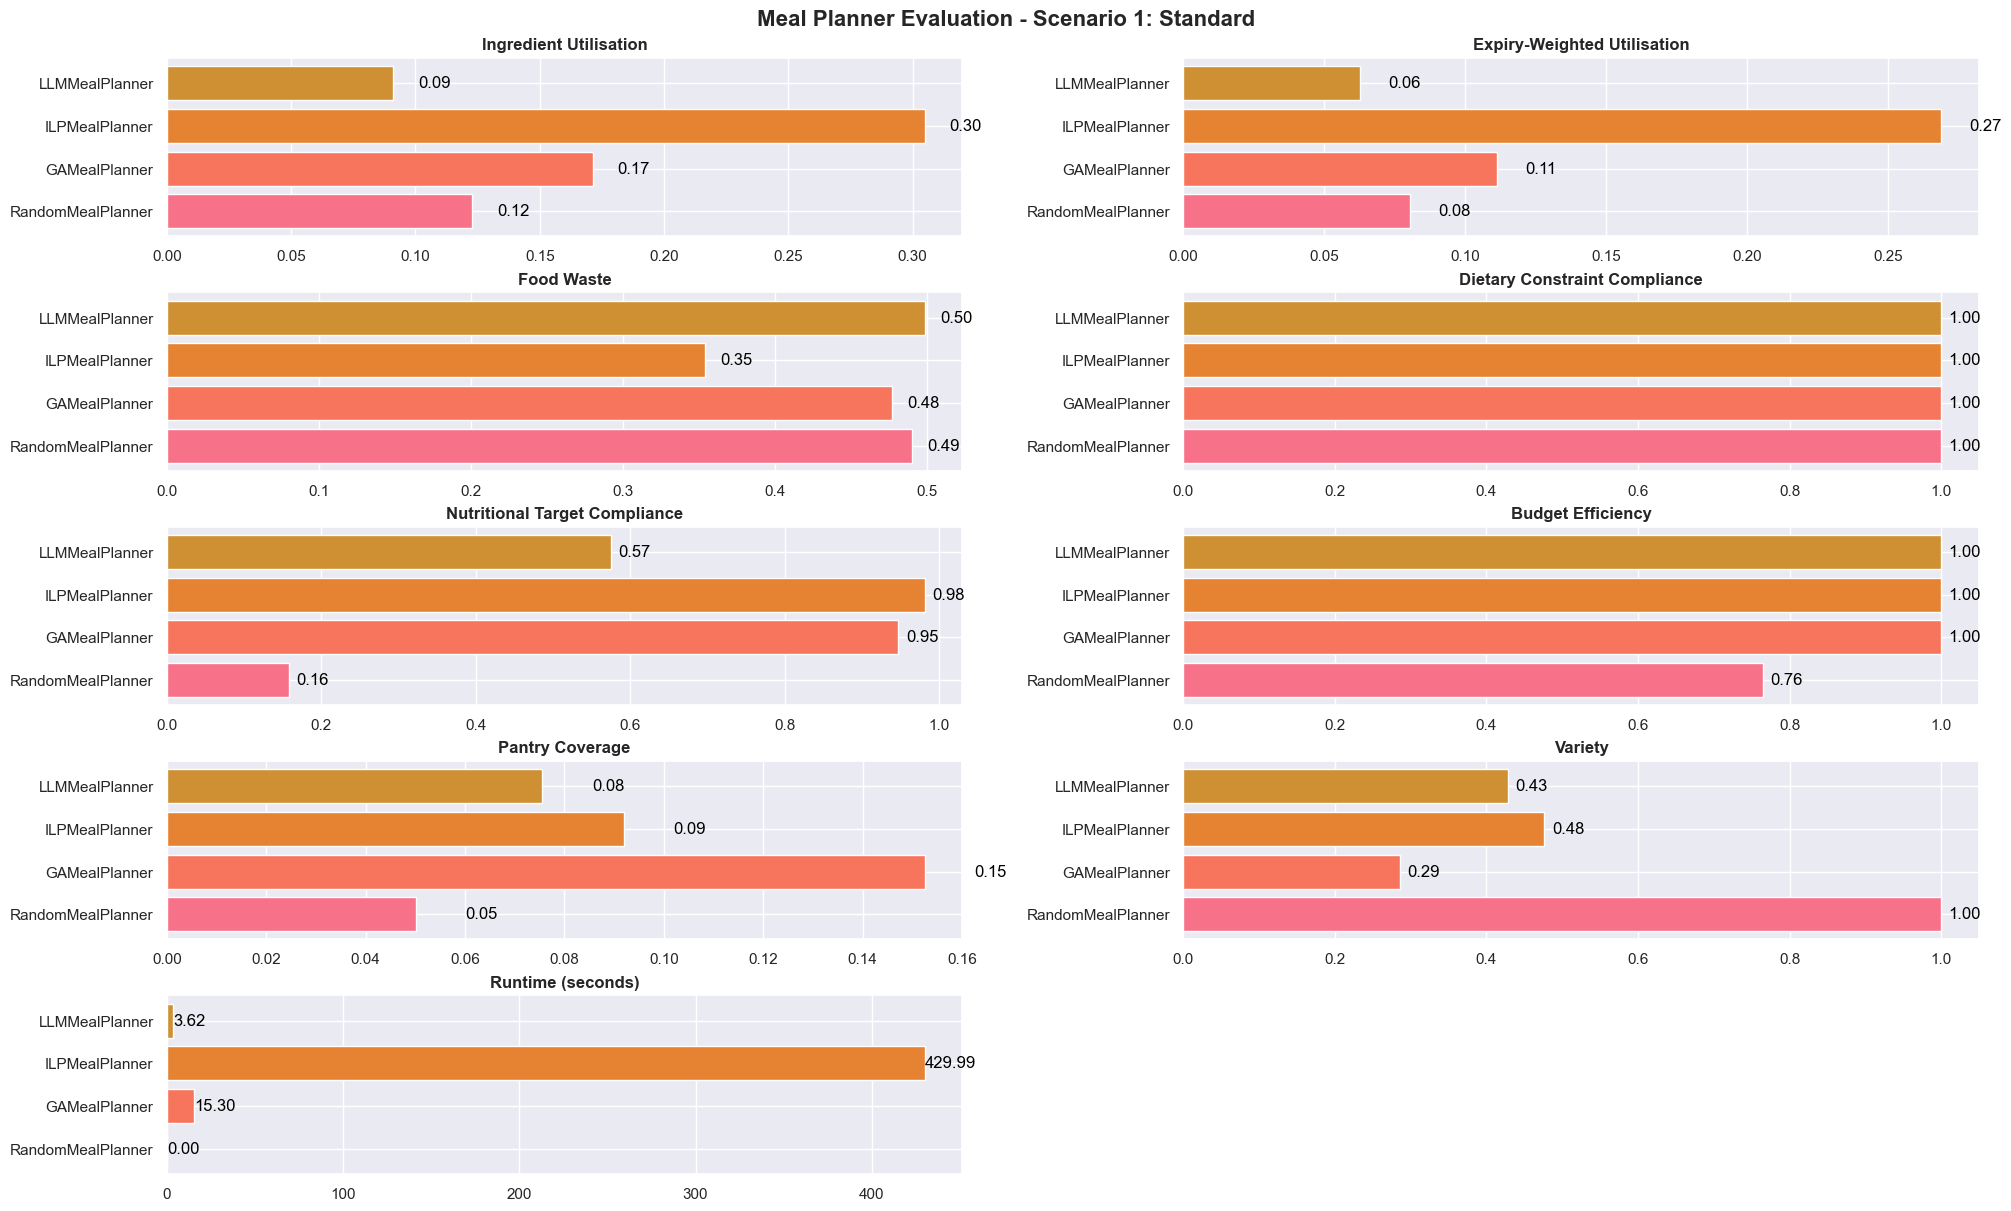

In [80]:
plot_metrics(scenario_1_metrics, f"Meal Planner Evaluation - {scenario_names[0]}")

In [81]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[0]} = {best_fitness_scores[('GAMealPlanner', 1)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 1)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 1: Standard = -0.2004 (GA), -0.1636 (ILP)


### Scenario 2

In [82]:
scenario_2_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 2}

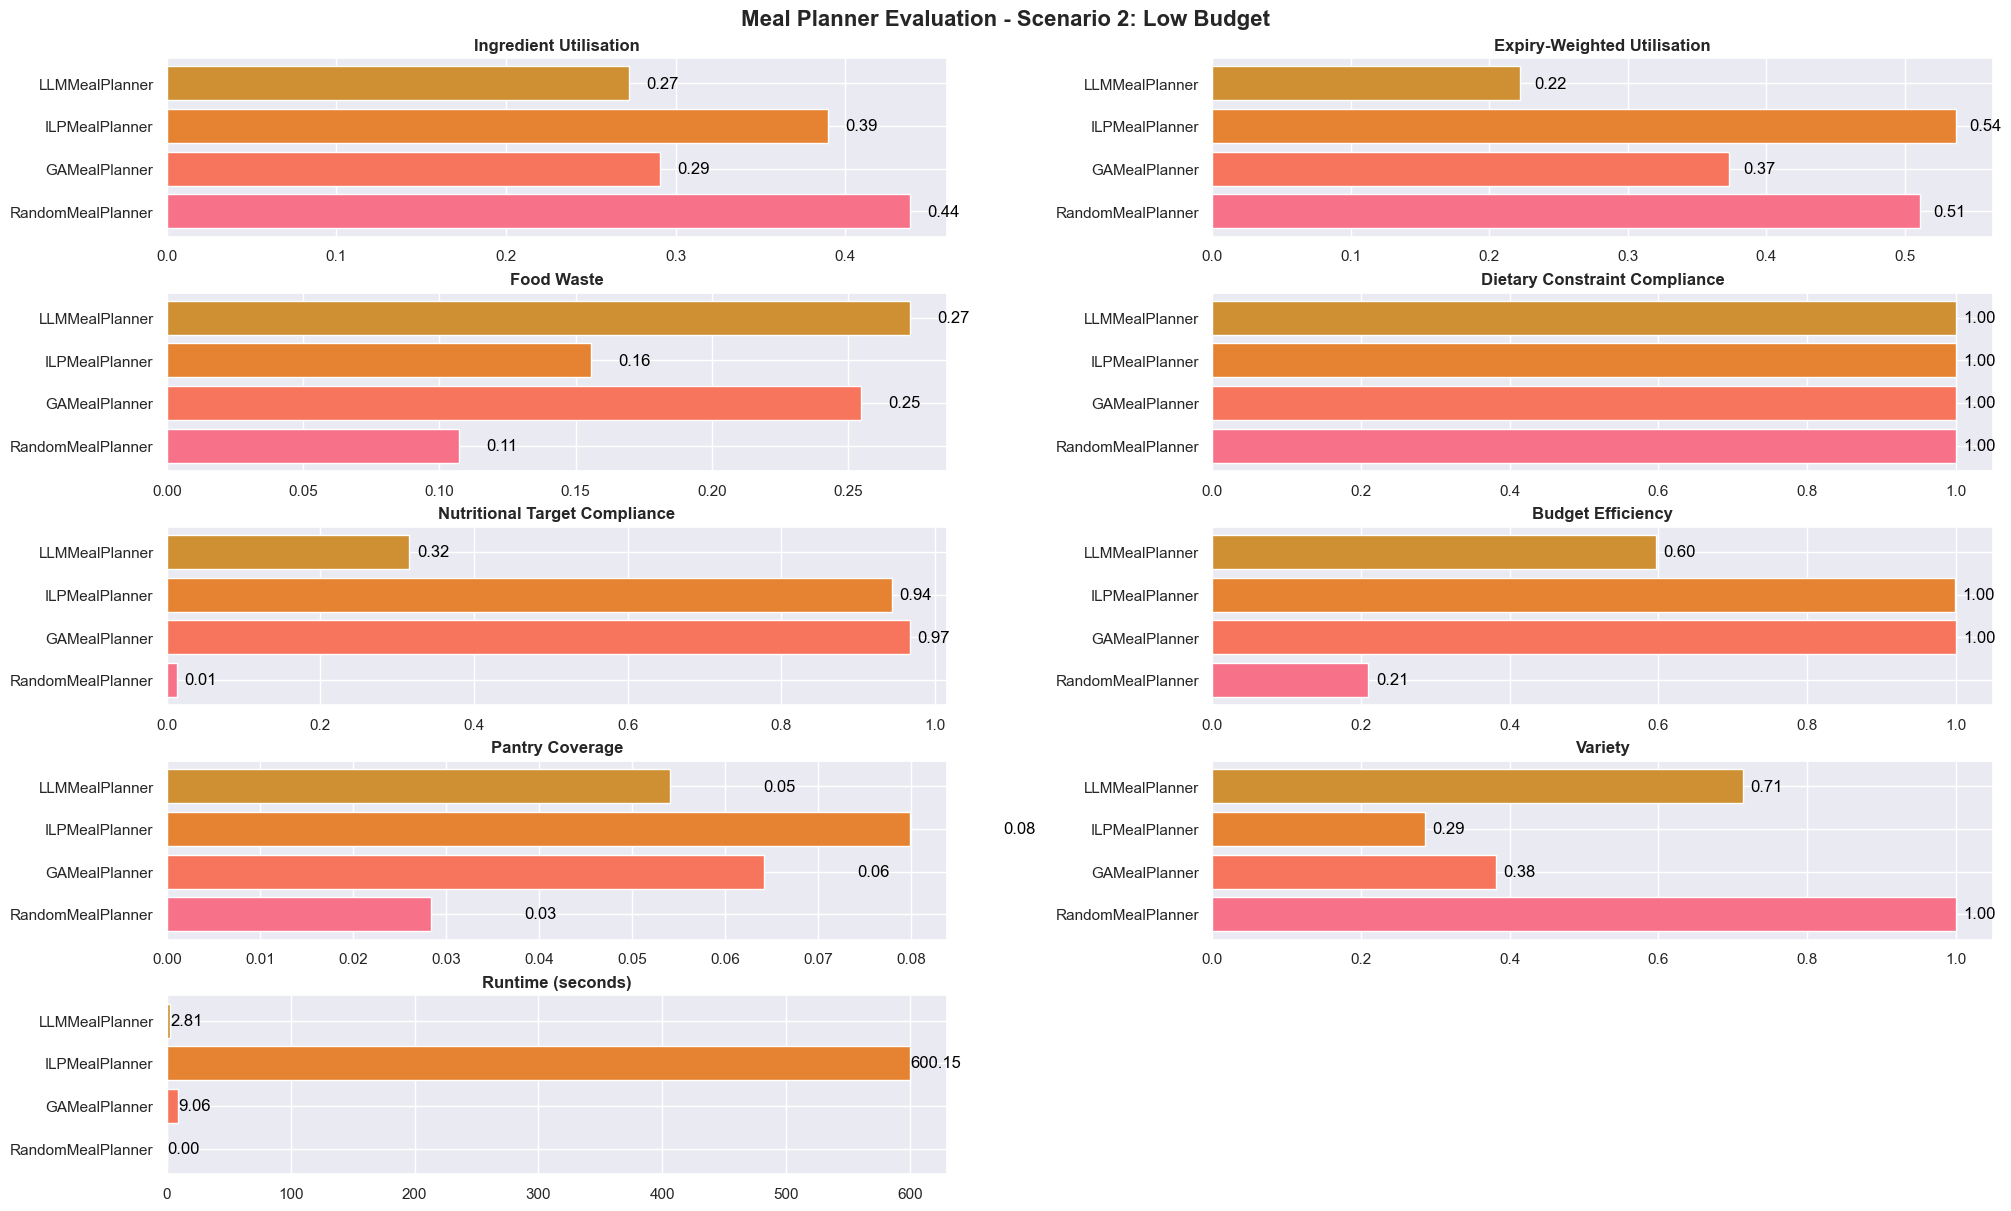

In [83]:
plot_metrics(scenario_2_metrics, f"Meal Planner Evaluation - {scenario_names[1]}")

In [84]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[1]} = {best_fitness_scores[('GAMealPlanner', 2)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 2)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 2: Low Budget = -0.07965 (GA), -0.02142 (ILP)


### Scenario 3

In [85]:
scenario_3_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 3}

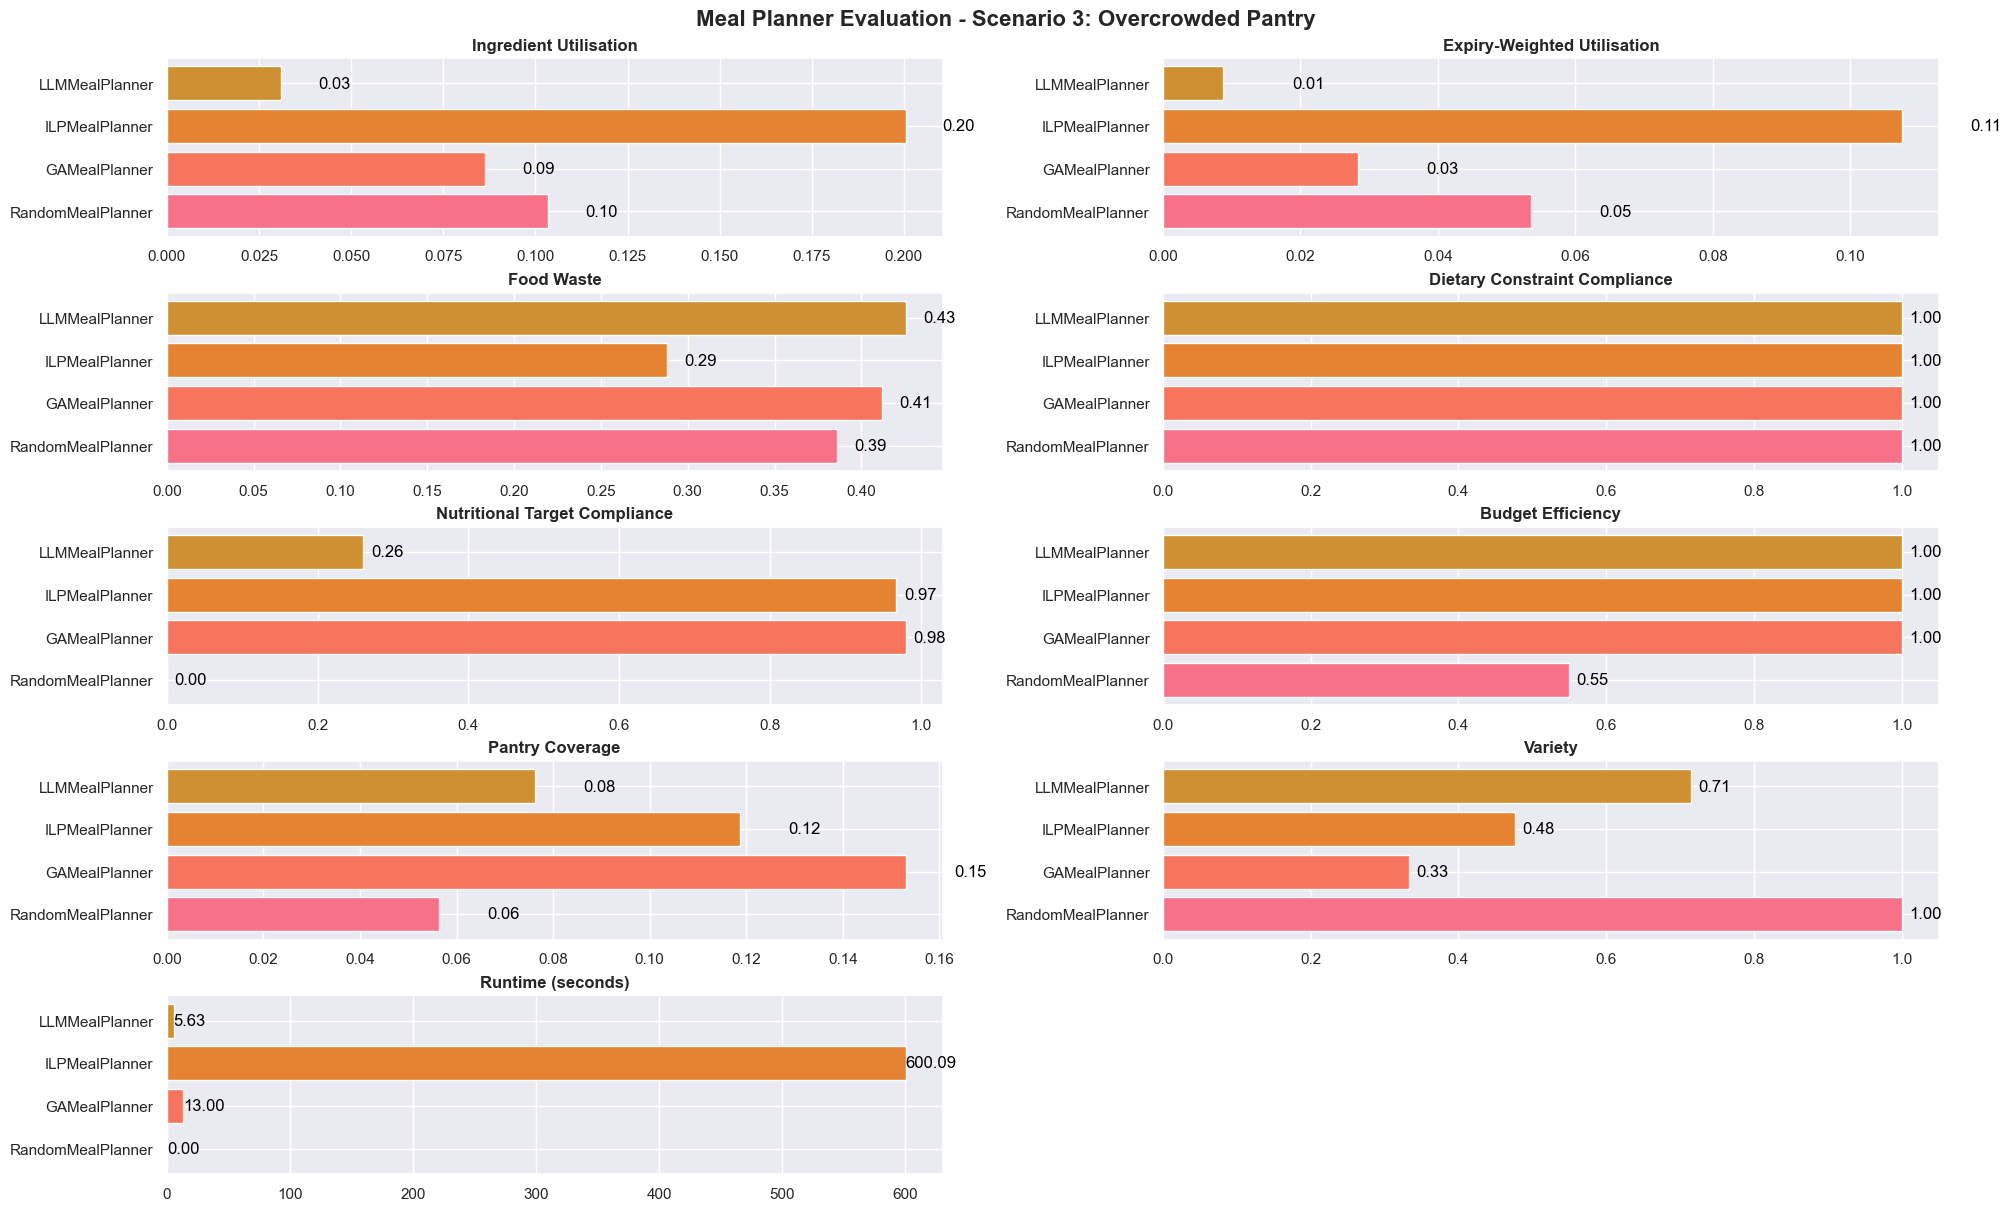

In [86]:
plot_metrics(scenario_3_metrics, f"Meal Planner Evaluation - {scenario_names[2]}")

In [87]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[2]} = {best_fitness_scores[('GAMealPlanner', 3)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 3)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 3: Overcrowded Pantry = -0.2149 (GA), -0.2154 (ILP)


### Scenario 4

In [88]:
scenario_4_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 4}

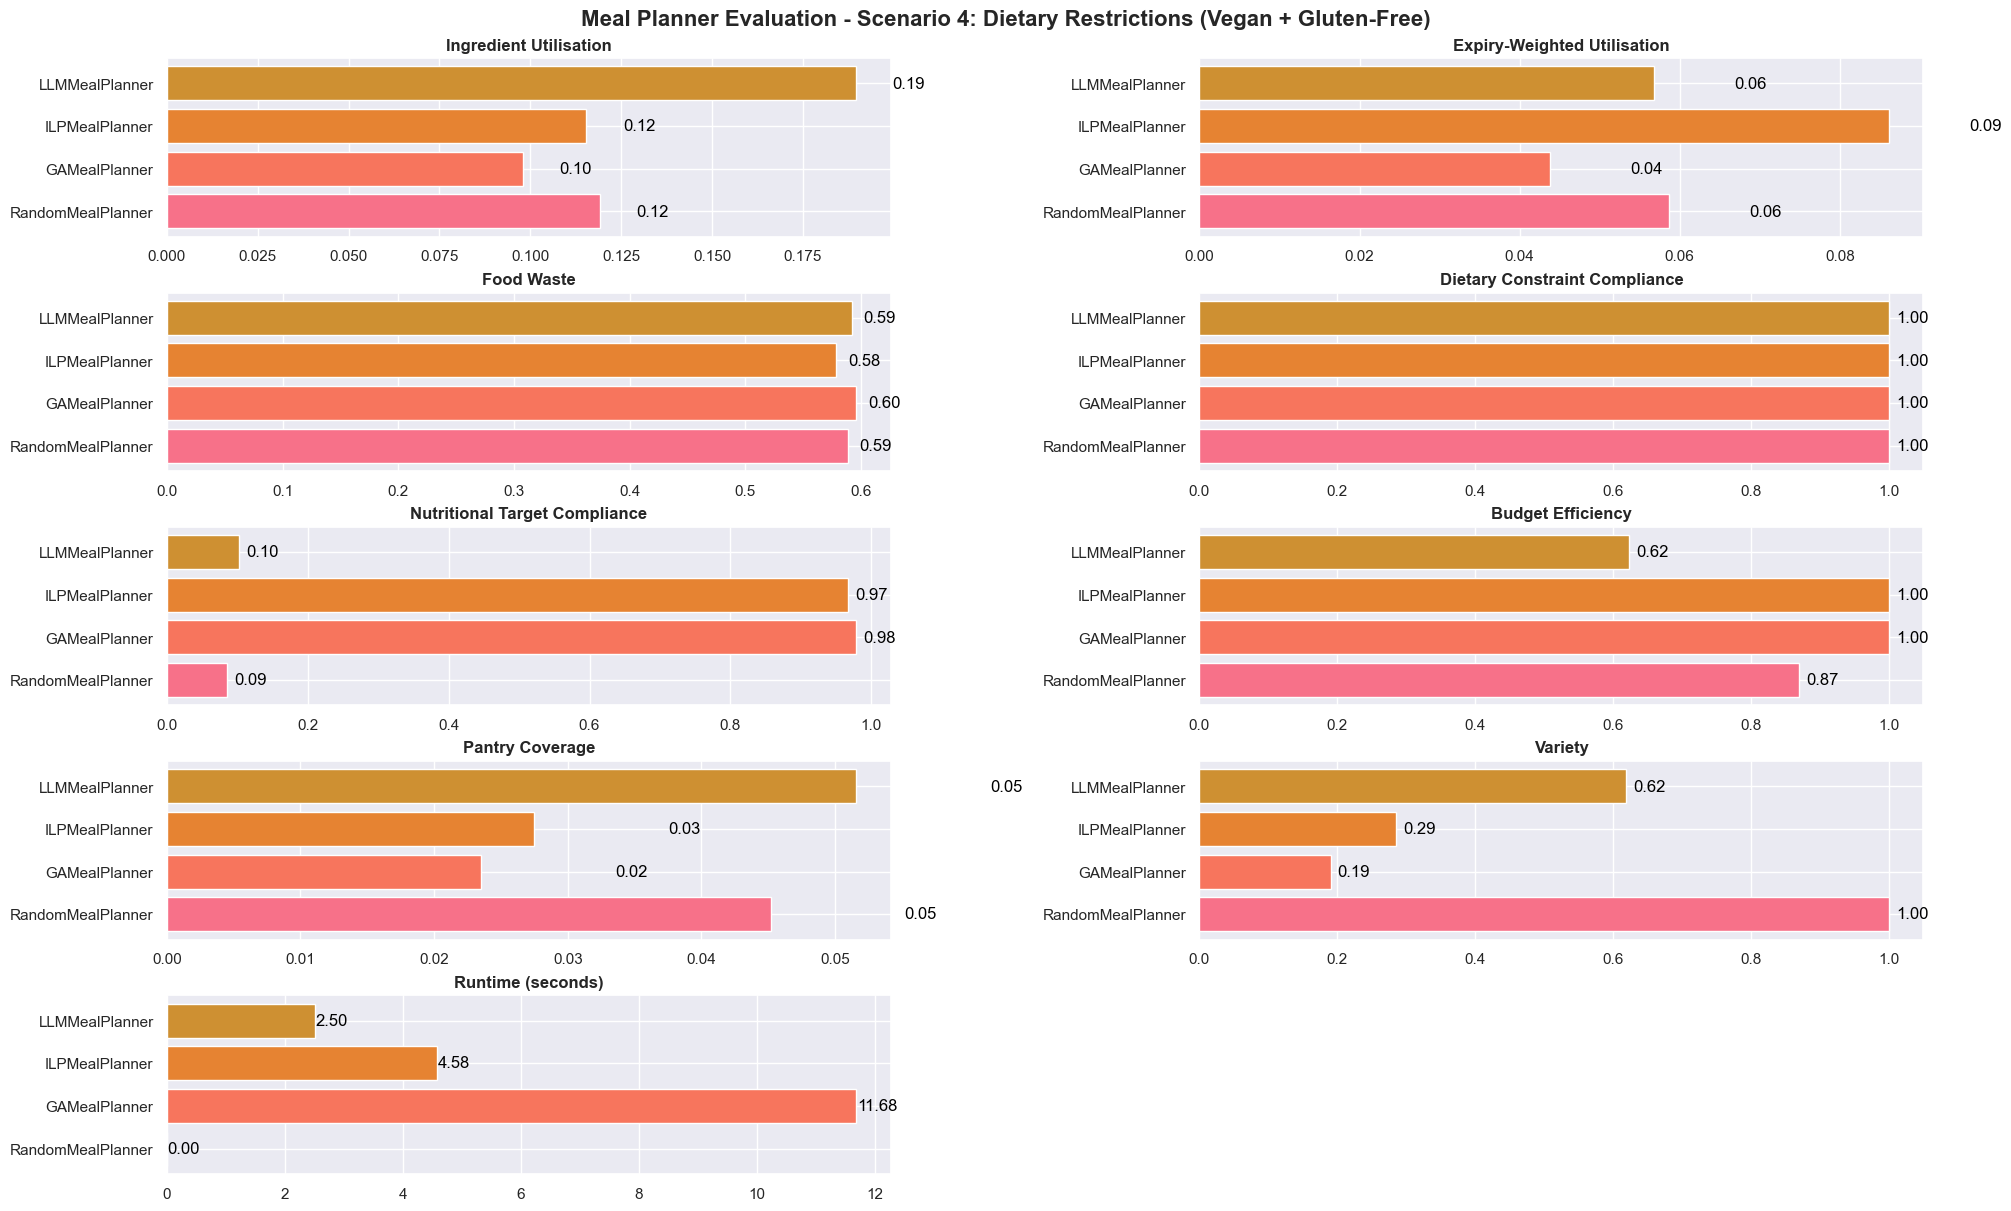

In [89]:
plot_metrics(scenario_4_metrics, f"Meal Planner Evaluation - {scenario_names[3]}")

In [90]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[3]} = {best_fitness_scores[('GAMealPlanner', 4)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 4)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 4: Dietary Restrictions (Vegan + Gluten-Free) = -0.354 (GA), -0.3472 (ILP)


### Scenario 5

In [91]:
scenario_5_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 5}

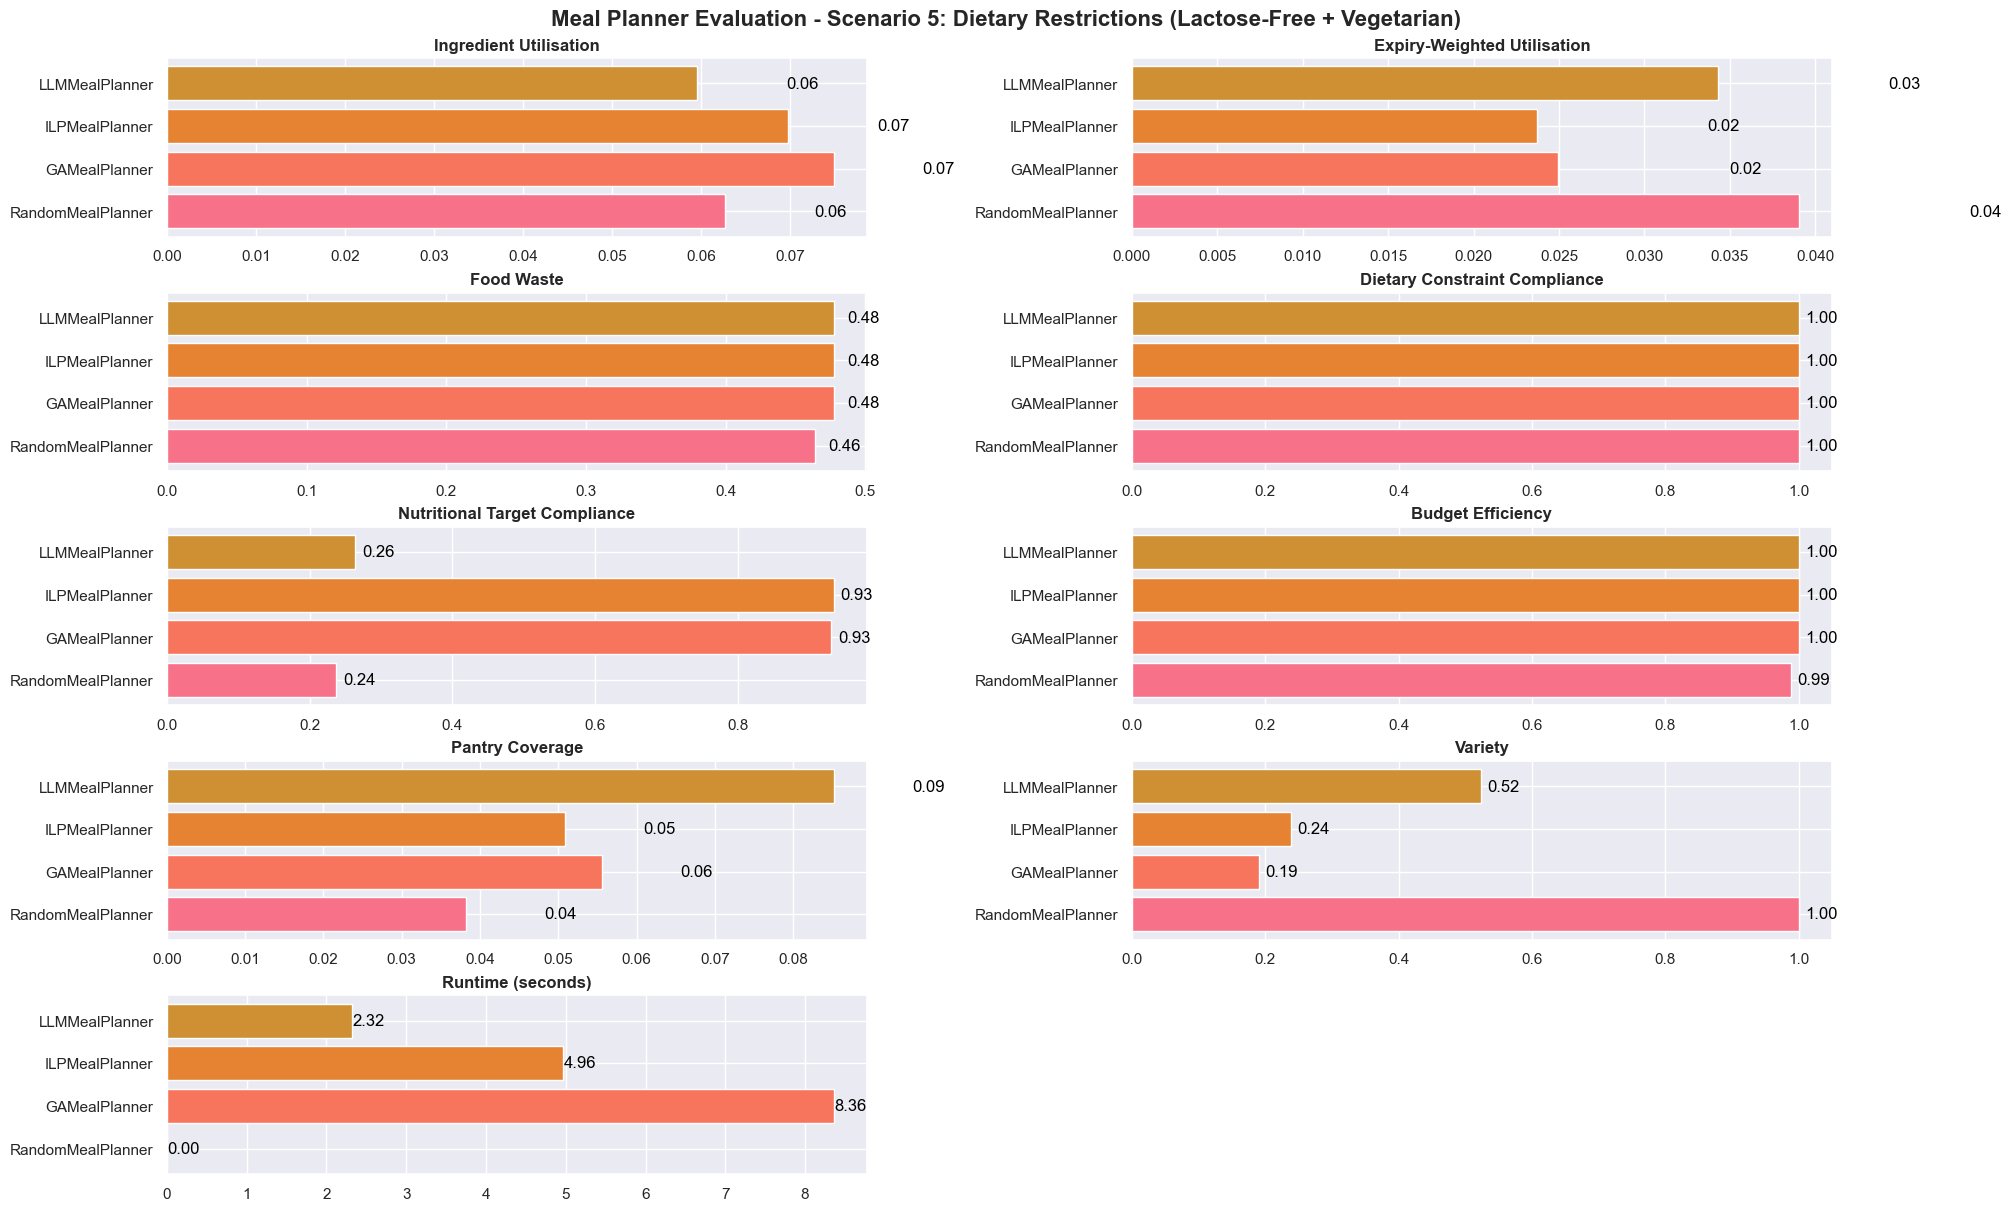

In [92]:
plot_metrics(scenario_5_metrics, f"Meal Planner Evaluation - {scenario_names[4]}")

In [93]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[4]} = {best_fitness_scores[('GAMealPlanner', 5)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 5)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 5: Dietary Restrictions (Lactose-Free + Vegetarian) = -0.2987 (GA), -0.3002 (ILP)


### Scenario 6

In [94]:
scenario_6_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 6}

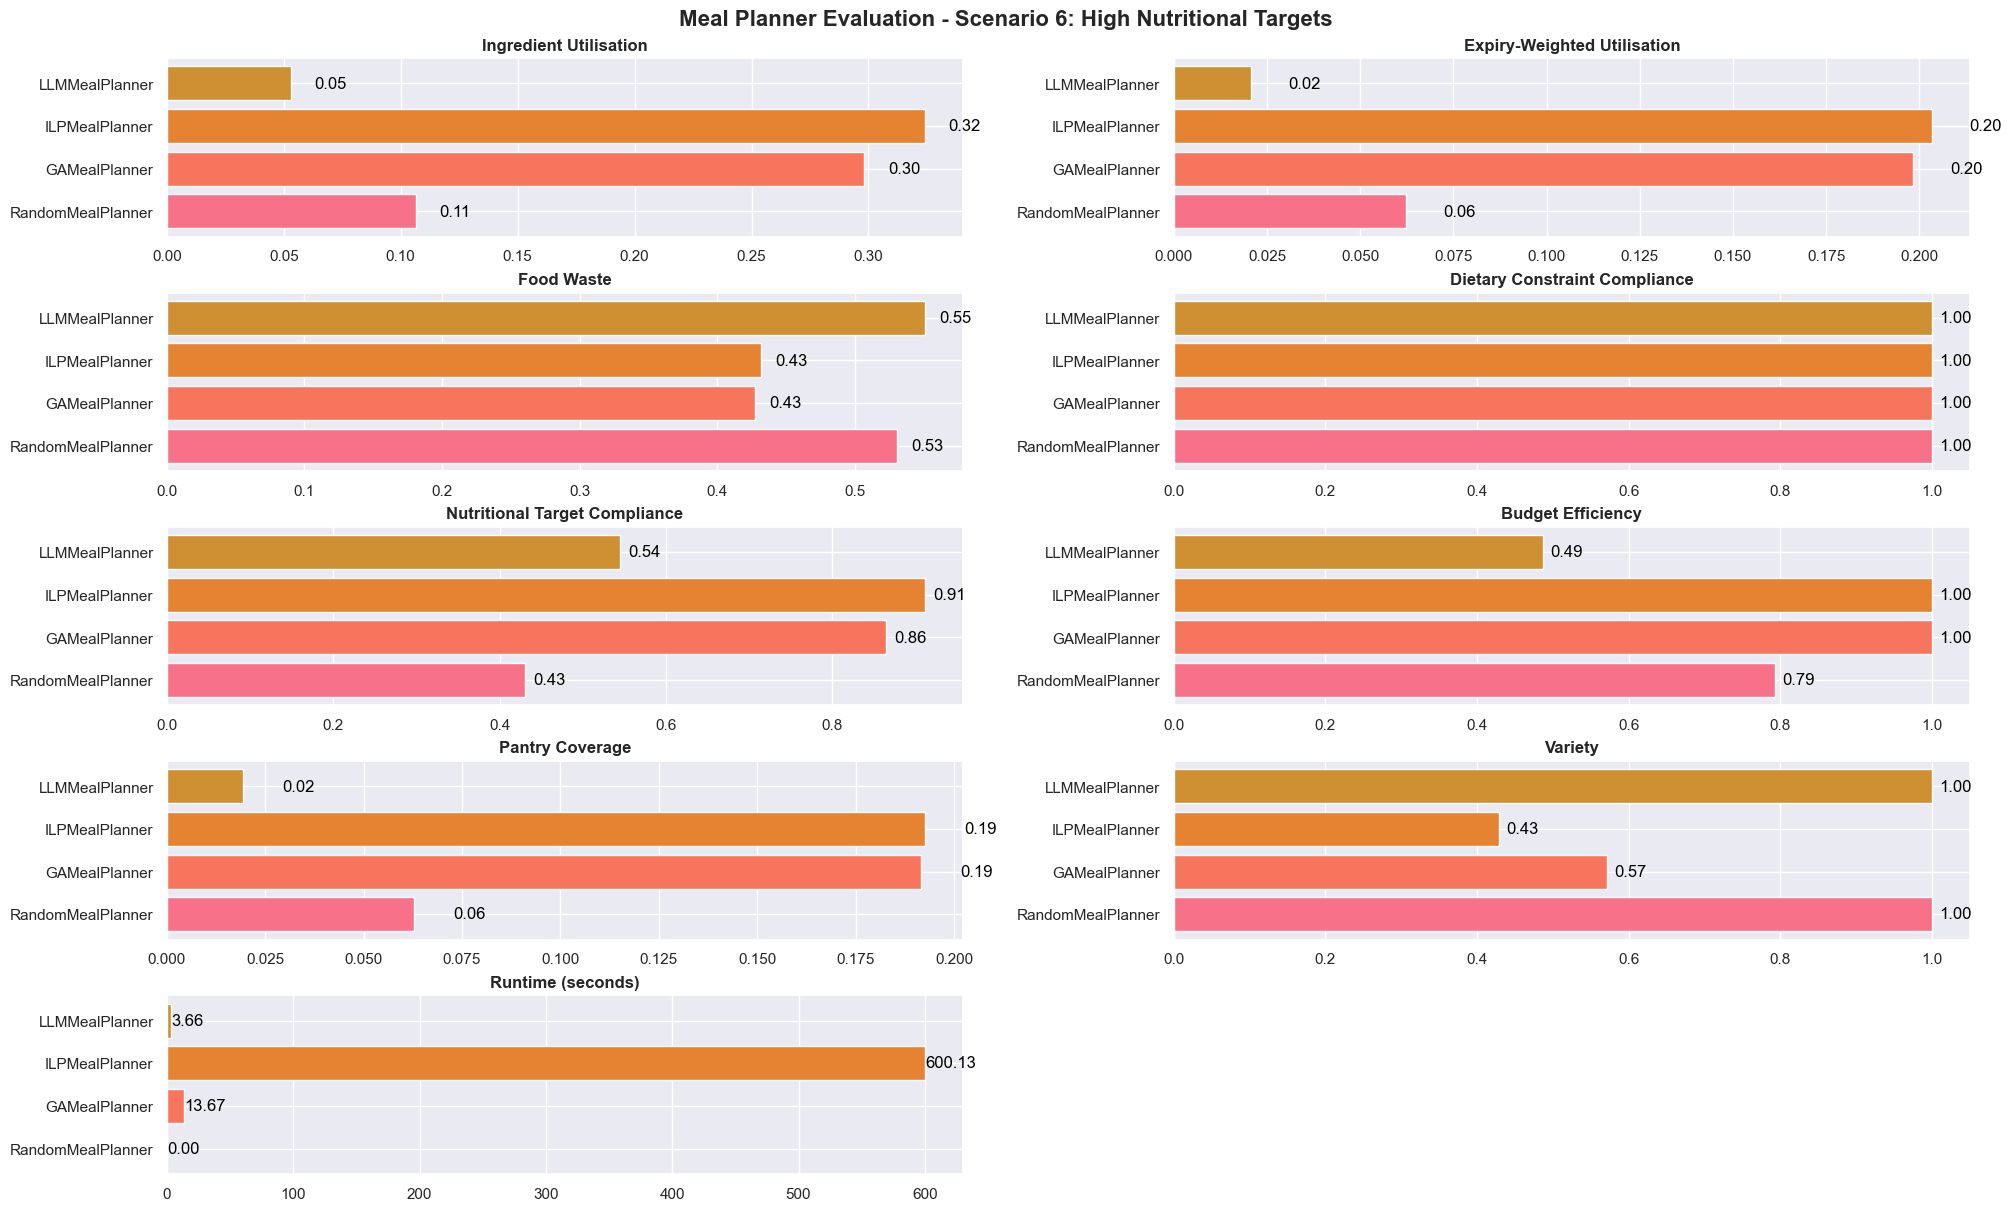

In [95]:
plot_metrics(scenario_6_metrics, f"Meal Planner Evaluation - {scenario_names[5]}")

In [96]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[5]} = {best_fitness_scores[('GAMealPlanner', 6)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 6)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 6: High Nutritional Targets = -0.2636 (GA), -0.218 (ILP)


### Average Across Scenarios

In [97]:
average_metrics: dict[str, dict[str, float]] = {}
average_fitness_scores: dict[str, float] = {}
planner_scenario_counts: dict[str, int] = {}

for planner_with_scenario_num, metrics in planner_metrics.items():
    planner_name, scenario_num = planner_with_scenario_num

    if planner_name not in average_metrics:
        average_metrics[planner_name] = {key: 0.0 for key in metrics}
        average_fitness_scores[planner_name] = 0.0
        planner_scenario_counts[planner_name] = 0

    for metric_key, metric_value in metrics.items():
        average_metrics[planner_name][metric_key] += metric_value

    fitness_score = best_fitness_scores.get((planner_name, scenario_num))
    if fitness_score is not None:
        average_fitness_scores[planner_name] += fitness_score

    planner_scenario_counts[planner_name] += 1

for planner_name, count in planner_scenario_counts.items():
    assert count == len(scenario_environments), (
        f"{planner_name} has {count} scenario entries, expected {len(scenario_environments)}"
    )
    for metric_key in average_metrics[planner_name]:
        average_metrics[planner_name][metric_key] /= count

    average_fitness_scores[planner_name] /= count


In [98]:
with open("./results/average_planner_metrics.json", "w") as file:
    json.dump(average_metrics, file, indent=4)

print("Saved average metrics to results/average_planner_metrics.json")

Saved average metrics to results/average_planner_metrics.json


In [99]:
with open("./results/average_fitness_scores.json", "w") as file:
    json.dump(average_fitness_scores, file, indent=4)

print("Saved average fitness scores to results/average_fitness_scores.json")

Saved average fitness scores to results/average_fitness_scores.json


In [100]:
average_metrics_df = DataFrame(average_metrics)
average_metrics_df

,RandomMealPlanner,GAMealPlanner,ILPMealPlanner,LLMMealPlanner
ingredient_utilisation_score_mean,0.158817,0.169949,0.234054,0.116169
ingredient_utilisation_score_std,0.044676,0.000000,0.000000,0.000000
expiry_weighted_utilisation_score_mean,0.134056,0.130016,0.204362,0.067601
expiry_weighted_utilisation_score_std,0.052423,0.000000,0.000000,0.000000
food_waste_score_mean,0.427786,0.440739,0.380922,0.469548
food_waste_score_std,0.033205,0.000000,0.000000,0.000000
dietary_constraint_compliance_mean,1.000000,1.000000,1.000000,1.000000
dietary_constraint_compliance_std,0.000000,0.000000,0.000000,0.000000
nutritional_target_score_mean,0.154117,0.944754,0.950709,0.343688
nutritional_target_score_std,0.100966,0.000000,0.000000,0.000000


In [101]:
average_fitness_scores_df = DataFrame({"Average Fitness Score": average_fitness_scores})
average_fitness_scores_df

,Average Fitness Score
RandomMealPlanner,0.000000
GAMealPlanner,-0.235208
ILPMealPlanner,-0.210986
LLMMealPlanner,0.000000


### GA vs ILP Comparison

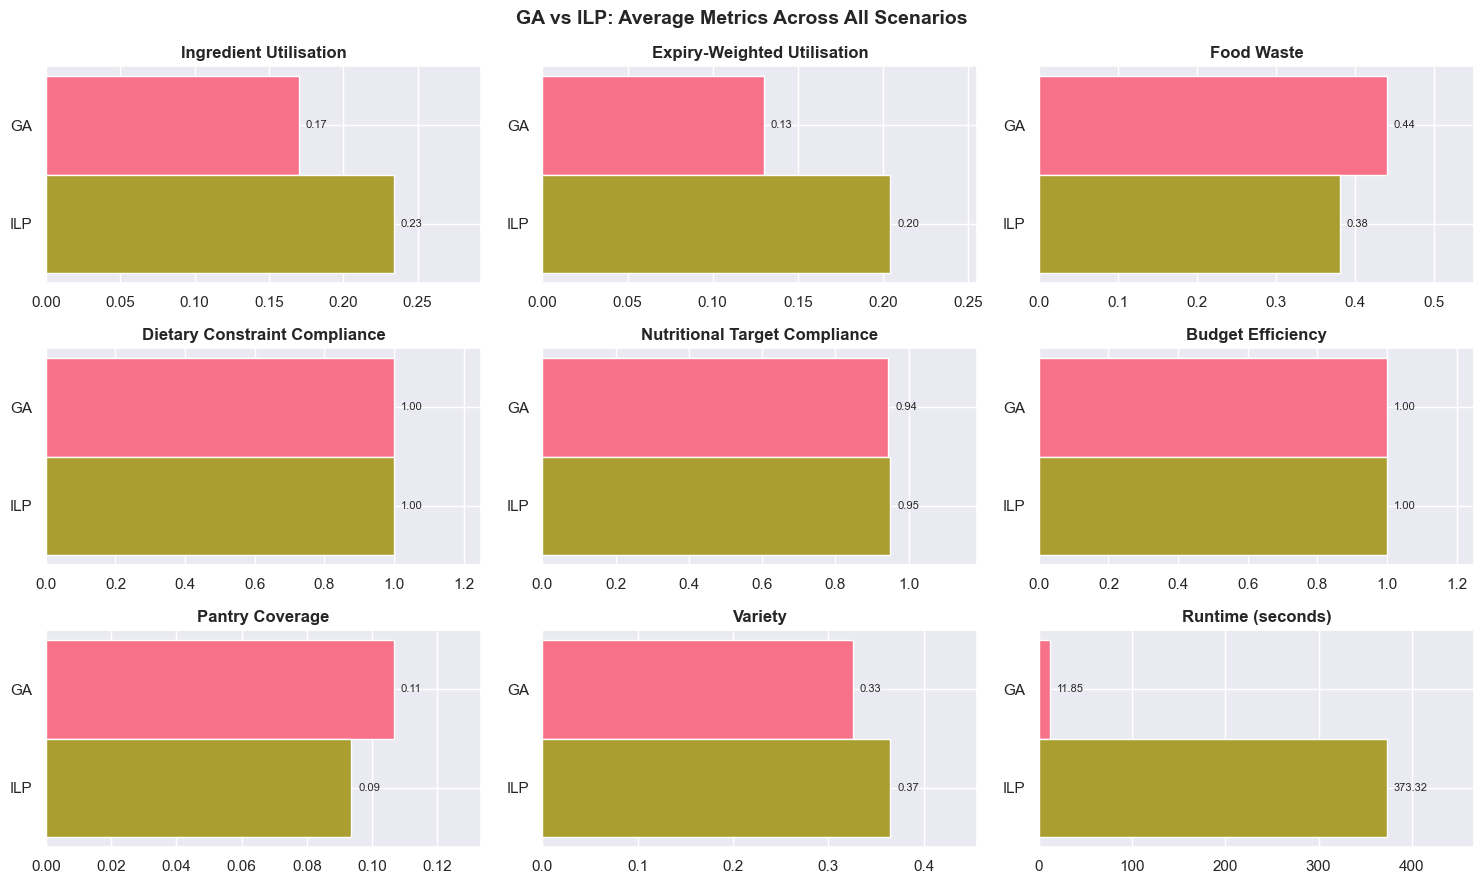

In [102]:
ga_metrics = average_metrics["GAMealPlanner"]
ilp_metrics = average_metrics["ILPMealPlanner"]

metric_labels = [label for _, label in metrics_to_plot]
metric_keys = [key for key, _ in metrics_to_plot]

n_metrics = len(metric_keys)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))

height = 0.35

for i, (metric_key, metric_label) in enumerate(zip(metric_keys, metric_labels)):
    ax = axes.flat[i]

    ga_val = ga_metrics[metric_key]
    ilp_val = ilp_metrics[metric_key]

    bar_ga = ax.barh(height / 2, ga_val, height, label="GA", color=colours[0])
    bar_ilp = ax.barh(-height / 2, ilp_val, height, label="ILP", color=colours[5])

    max_val = max(ga_val, ilp_val)
    offset = max_val * 0.02

    ax.text(ga_val + offset, height / 2, f"{ga_val:.2f}", va="center", fontsize=8)
    ax.text(ilp_val + offset, -height / 2, f"{ilp_val:.2f}", va="center", fontsize=8)

    ax.set_xlim(0, max_val * 1.25)
    ax.set_yticks([height / 2, -height / 2])
    ax.set_yticklabels(["GA", "ILP"])
    ax.set_title(metric_label, fontweight="bold")

# hide any unused subplots
for j in range(n_metrics, n_rows * n_cols):
    axes.flat[j].set_visible(False)

fig.suptitle("GA vs ILP: Average Metrics Across All Scenarios", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()